In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import re

In [71]:
# Consumption data
Material_Consumption_url = 'https://github.com/FairzanIsLearning/OralLeptinExploration/blob/main/Green%20metrics/Material_consumption.csv?raw=true'
Material_consumption_rawdata = pd.read_csv(Material_Consumption_url)
# materials are in mg and solvents are in mL

Material_consumption_rawdata.rename(columns={'H20_Volume_HCl_2': 'H20_Weight_HCl_2'}, inplace=True)

In [60]:
# store reference data (MW, density)
Material_Dictionary_Rawdata = {
    "MW" : [337.33, 105.99, 120.336, 131.7, 353.4, 353.4,  204.23, 426.46, 89.09, 311.33, 131.17, 337.37, 157.62, 343.4, 18.01, 88.11, 84.93,86.18, 36.46, 60.08, 119.37, 32.04, 60.05, 131.7, 204.23, 89.09, 131.17, 121.16],
    "Density" : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1000, 1033, 1325, 660, 1015, 0, 1489.2, 792, 1040, 0, 0, 0, 0, 0]
}

material_index = [
    'Fmoc-OSU', 'Na2CO3', 'MgSO4', 'Leu', 'Fmoc-L-Leu', 'Fmoc-D-Leu',
    'Trp', 'Fmoc-Trp', 'Ala', 'Fmoc-L-Ala', 'Pro', 'Fmoc-Pro',
    'Cys.HCl', 'Fmoc-Cys', 'H2O', 'Dioxane', 'DCM', 'Hexane', 'HCl',
    'Silica', 'Chloroform', 'MeOH', 'Acetic acid', 'Leu', 'Trp', 'Ala', 'Pro', 'Cys'
]

mat_prop = pd.DataFrame(Material_Dictionary_Rawdata, index=material_index)

In [61]:
# Define material type and whats used in each stage

# Define material type
Raw_material_Set = ['AA', 'Fmoc-OSU']
Solvent_Set = ['H2O', 'Dioxane', 'DCM', 'Hexane', 'Chloroform', 'MeOH', 'Acetic acid']
Auxiliary_Set = ['Silica', 'MgSO4']
Reagent_Set = ['HCl', 'Na2CO3']

# Define materials for each stage
Synthesis_Material = ['Dioxane', 'Na2CO3', 'Fmoc-OSU', 'AA', 'H20_1']
Extraction_material = ['Hexane_2', 'HCl', 'DCM_2', 'MgSO4', 'H20_2']
Purification_material = ['Silica sample', 'Chloroform', 'Acetic acid', 'MeOH', 'Silica col', 'DCM_3', 'Hexane_3']

# Add silica sub-types (they share the same MW/density as 'Silica')
mat_prop.loc['Silica sample'] = mat_prop.loc['Silica']
mat_prop.loc['Silica col']   = mat_prop.loc['Silica']

In [93]:
# function to determine amino acid being processed
def AA_material_from_product(product):
    """
    Extracts the free amino acid material name from a product code.
    Examples:
        'Fmoc-L-Leu'   -> 'Leu'
        'Fmoc-D-Leu'   -> 'Leu'
        'Fmoc-Trp'     -> 'Trp'
        'Fmoc-Cys'     -> 'Cys.HCl'
        'Fmoc-L-Ala'   -> 'Ala'
        'Fmoc-Pro'     -> 'Pro'
    """
    # Remove 'Fmoc-' and optional L- or D- prefix
    code = re.sub(r'^Fmoc-(L-|D-)?', '', str(product)).strip()
    
    # Explicit mapping for known amino acids (extend if needed)
    aa_map = {
        'Leu': 'Leu',
        'Trp': 'Trp',
        'Ala': 'Ala',
        'Pro': 'Pro',
        'Cys': 'Cys.HCl',
        # Add more if needed, e.g. 'Phe': 'Phe', 'Gly': 'Gly'
    }
    if code in aa_map:
        return aa_map[code]
    else:
        # If a new amino acid appears, raise a warning so you can add it to the map
        print(f'WARNING: Unrecognized amino acid code "{code}" from product "{product}".'
              ' Please add it to aa_map.')
        return code  # fallback to the raw code

In [63]:
# functions to classify the materials
def classify_material(material):
    if material in Raw_material_Set:
        return 'Raw material'
    if material in Solvent_Set:
        return 'Solvent'
    if material in Auxiliary_Set:
        return 'Auxiliary'
    if material in Reagent_Set:
        return 'Reagent'
    return 'Other'

def parse_col(col):
    col_lower = col.lower()
    if 'weight' in col_lower:
        mtype = 'Weight'
    elif 'volume' in col_lower:
        mtype = 'Volume'
    else:
        return None

    # Stage from trailing digit (e.g. DCM_Volume_2 -> 2)
    stage_match = re.search(r'_?(\d+)$', col)
    if stage_match:
        stage = int(stage_match.group(1))
    else:
        stage = None

    # Map column prefix to standard material name
    if col_lower.startswith('aa_weight'):
        return ('AA', mtype, stage)
    elif col_lower.startswith('fmoc_weight'):
        return ('Fmoc-OSU', mtype, stage)
    elif col_lower.startswith('na2co3_weight'):
        return ('Na2CO3', mtype, stage)
    elif col_lower.startswith('mgso4_weight'):
        return ('MgSO4', mtype, stage)
    elif col_lower.startswith('h2o_volume') or col_lower.startswith('h2o_weight'):
        return ('H2O', mtype, stage)
    elif col_lower.startswith('dioxane_volume') or col_lower.startswith('dioxane_weight'):
        return ('Dioxane', mtype, stage)
    elif col_lower.startswith('dcm_volume') or col_lower.startswith('dcm_weight'):
        return ('DCM', mtype, stage)
    elif col_lower.startswith('hexane_volume') or col_lower.startswith('hexane_weight'):
        return ('Hexane', mtype, stage)
    elif col_lower.startswith('hcl_volume') or col_lower.startswith('hcl_weight'):
        return ('HCl', mtype, stage)
    elif col_lower.startswith('h20_volume_hcl'):
        return ('H2O', mtype, 2)
    elif col_lower.startswith('silicasample_weight'):
        return ('Silica sample', mtype, 3)
    elif col_lower.startswith('silicacolumn_weight'):
        return ('Silica col', mtype, 3)
    elif col_lower.startswith('chloroform_volume') or col_lower.startswith('chloroform_weight'):
        return ('Chloroform', mtype, stage)
    elif col_lower.startswith('meoh_volume') or col_lower.startswith('meoh_weight'):
        return ('MeOH', mtype, stage)
    elif col_lower.startswith('acoh_volume') or col_lower.startswith('acoh_weight'):
        return ('Acetic acid', mtype, stage)
    return None

In [94]:
# unite all the materials classification
melted_parts = []
for col in Material_consumption_rawdata.columns:
    info = parse_col(col)
    if info is None:
        continue
    material, mtype, stage = info
    temp = Material_consumption_rawdata[['Code', 'Product', 'Puritication_system', col]].copy()
    temp.rename(columns={col: 'value'}, inplace=True)
    temp['Material'] = material
    temp['Measurement'] = mtype
    temp['Stage'] = stage
    melted_parts.append(temp)

long_df = pd.concat(melted_parts, ignore_index=True)

# Replace generic 'AA' with the amino acid
mask_aa = long_df['Material'] == 'AA'
if mask_aa.any():
    long_df.loc[mask_aa, 'Material'] = long_df.loc[mask_aa, 'Product'].apply(AA_material_from_product)
    # Verify that no 'AA' remains
    remaining_AA = (long_df['Material'] == 'AA').sum()
    if remaining_AA > 0:
        print(f'WARNING: {remaining_AA} rows still have Material="AA" after mapping.')
else:
    print('No "AA" rows found – mapping was not needed.')

In [95]:
# Complete the dataframe with mass information
w = long_df[long_df['Measurement'] == 'Weight'].drop(columns='Measurement').rename(columns={'value': 'Weight_mg'})
v = long_df[long_df['Measurement'] == 'Volume'].drop(columns='Measurement').rename(columns={'value': 'Volume_ml'})

merged = pd.merge(w, v, on=['Code', 'Product', 'Puritication_system', 'Material', 'Stage'], how='outer')

# moles calculation
merged = merged.merge(mat_prop[['MW', 'Density']], left_on='Material', right_index=True, how='left')
merged['Mass_mg'] = merged['Weight_mg'].fillna(merged['Volume_ml'] * merged['Density'])
merged['Mol'] = merged['Mass_mg'] / (merged['MW'] * 1000)

# add to the df
merged['Material_Type'] = merged['Material'].apply(classify_material)

Material_consumption_process = merged[['Code', 'Product', 'Puritication_system', 'Stage',
                  'Material', 'Material_Type', 'Mass_mg', 'Mol']]

In [ ]:
# Define customized colour based on its hazard level
custom_colors = {
    # solvent
    'H2O': 'lightblue',
    'Dioxane': 'mistyrose',
    'DCM': 'palevioletred',
    'Hexane': 'orangered',
    'HCl' : 'gold',
    'Chloroform': 'crimson',
    'Acetic acid': 'lightsalmon',
    'MeOH': 'sandybrown',
    
    # material
    'Fmoc-OSU': 'snow',
    'Na2CO3': 'snow',
    'MgSO4': 'snow',
    'Silica sample': 'lightgrey',
    'Silica col': 'lightgrey',
}

# Fallback colour if a material is not in the dictionary
fallback_color = 'lightgrey' #idk eh  

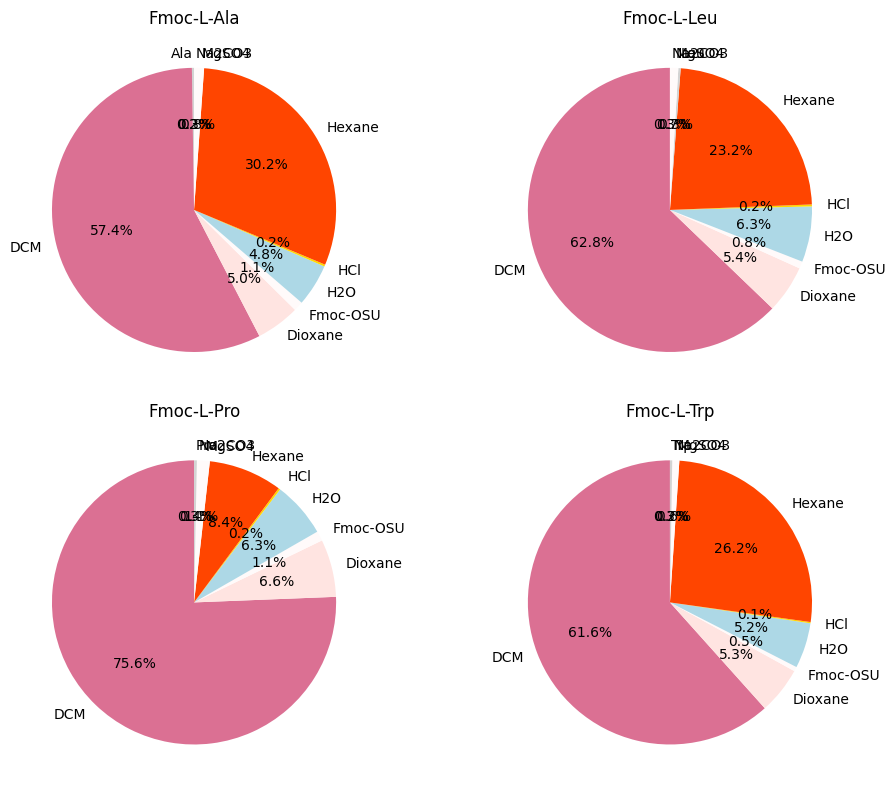

In [ ]:
# visualize material consumption for synthesis and extraction stage
stages_12 = Material_consumption_process[Material_consumption_process['Stage'].isin([1,2])].copy()

# Group by product and material, compute mean mass
prod_avg = stages_12.groupby(['Product', 'Material'])['Mass_mg'].mean().reset_index()
products = prod_avg['Product'].unique()

# Set up subplots: one pie chart per product
n_products = len(products)
cols = 2
rows = int(np.ceil(n_products / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
if n_products == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for ax, product in zip(axes, products):
    data = prod_avg[prod_avg['Product'] == product]
    # Use data['Material'] – the materials in this specific product's slice
    colors = [custom_colors.get(mat, fallback_color) for mat in data['Material']]
    ax.pie(data['Mass_mg'], labels=data['Material'], colors=colors, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'{product}')
# Hide unused subplots
for j in range(len(products), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# create a dataframe with only solvent data
solvents_df = Material_consumption_process[Material_consumption_process['Material_Type'] == 'Solvent']

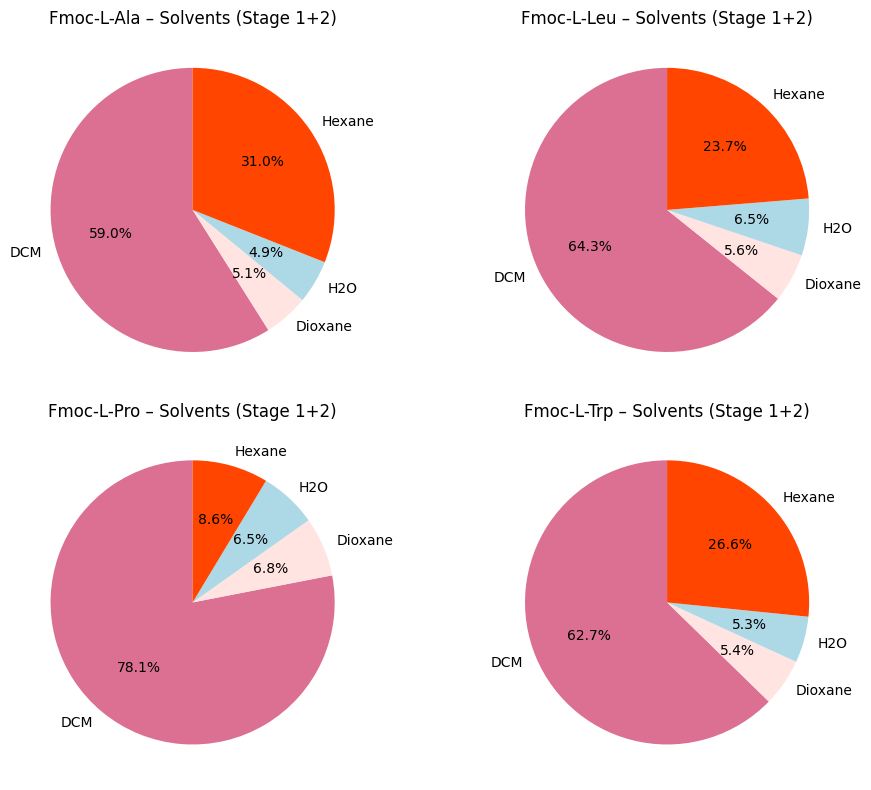

In [ ]:
# visualize solvent consumption in different amino acid protection
stages_12 = solvents_df[solvents_df['Stage'].isin([1, 2])].copy()
prod_avg = stages_12.groupby(['Product', 'Material'])['Mass_mg'].mean().reset_index()

products = prod_avg['Product'].unique()
n_products = len(products)
cols = 2
rows = int(np.ceil(n_products / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
if n_products == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for ax, product in zip(axes, products):
    data = prod_avg[prod_avg['Product'] == product]
    colors = [custom_colors.get(mat, fallback_color) for mat in data['Material']]
    ax.pie(data['Mass_mg'], labels=data['Material'], colors=colors,
           autopct='%1.1f%%', startangle=90)
    ax.set_title(f'{product} – Solvents (Stage 1+2)')

# Hide unused subplots
for j in range(len(products), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

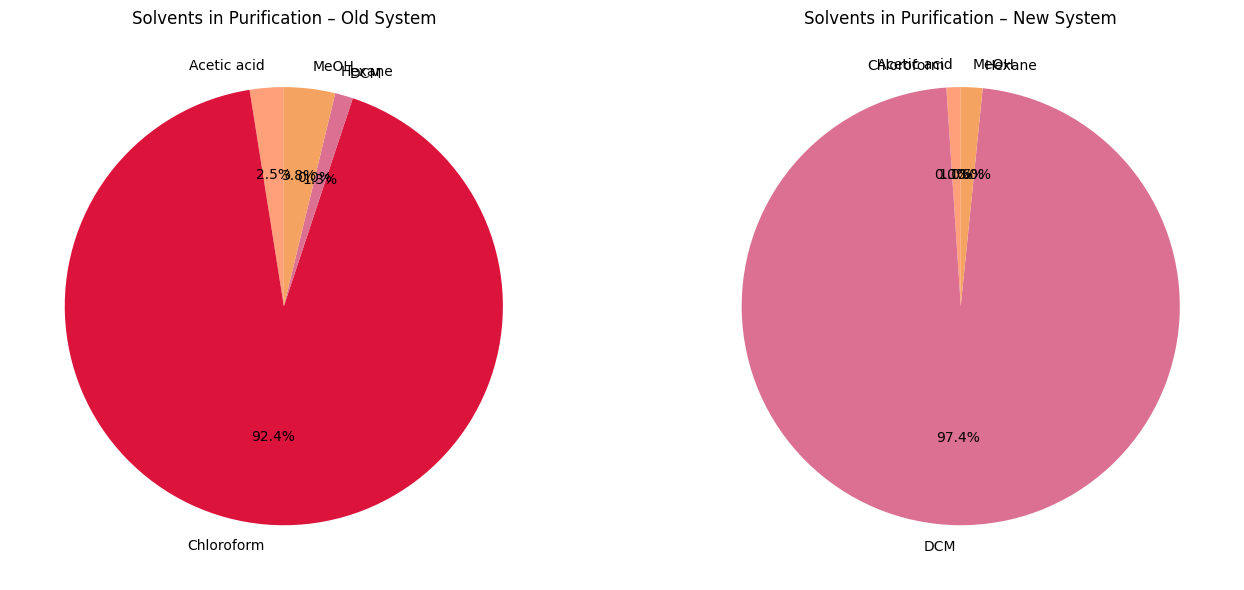

In [124]:
# visualize solvent consumption during purification stage in different main solvent
stage3 = solvents_df[solvents_df['Stage'] == 3].copy()
pur_avg = stage3.groupby(['Puritication_system', 'Material'])['Mass_mg'].mean().reset_index()

old_pur = pur_avg[pur_avg['Puritication_system'] == 'old']
new_pur = pur_avg[pur_avg['Puritication_system'] == 'new']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Old system
if not old_pur.empty:
    colors_old = [custom_colors.get(mat, fallback_color) for mat in old_pur['Material']]
    ax1.pie(old_pur['Mass_mg'], labels=old_pur['Material'], colors=colors_old,
            autopct='%1.1f%%', startangle=90)
    ax1.set_title('Solvents in Purification – Old System')
else:
    ax1.text(0.5, 0.5, 'No data', ha='center', va='center')

# New system
if not new_pur.empty:
    colors_new = [custom_colors.get(mat, fallback_color) for mat in new_pur['Material']]
    ax2.pie(new_pur['Mass_mg'], labels=new_pur['Material'], colors=colors_new,
            autopct='%1.1f%%', startangle=90)
    ax2.set_title('Solvents in Purification – New System')
else:
    ax2.text(0.5, 0.5, 'No data', ha='center', va='center')

plt.tight_layout()
plt.show()

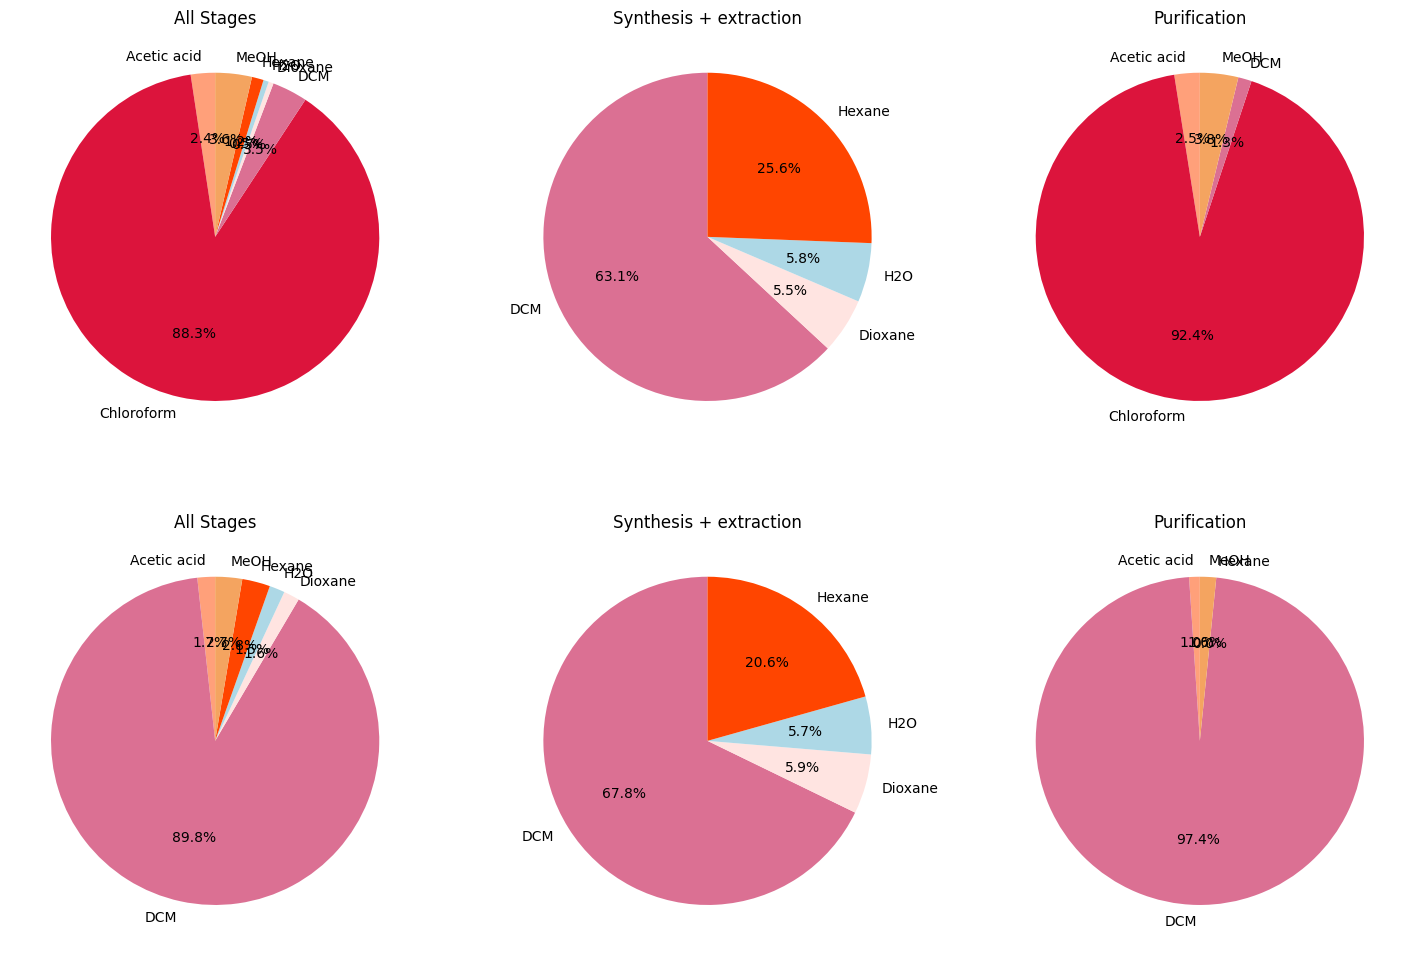

In [127]:
# visualize material consumption for all stages in different main purification solvent
stage_groups = {
    'All Stages':      [1, 2, 3],
    'Synthesis + extraction':       [1, 2],
    'Purification':         [3]
}
system_labels = ['Chloroform‑based', 'DCM‑based']
systems = ['old', 'new'] 

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

avg_data = avg_data[avg_data['Mass_mg'] > 0]


for row_idx, system in enumerate(systems):
    system_data = solvents_df[solvents_df['Puritication_system'] == system]

    for col_idx, (group_name, stages) in enumerate(stage_groups.items()):
        ax = axes[row_idx, col_idx]

        group_data = system_data[system_data['Stage'].isin(stages)]

        if group_data.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{system_labels[row_idx]} – {group_name}')
            continue

        # Compute mean mass per material
        avg_data = group_data.groupby('Material')['Mass_mg'].mean().reset_index()

        # Exclude materials with zero mass
        avg_data = avg_data[avg_data['Mass_mg'] > 0]

        if avg_data.empty:
            ax.text(0.5, 0.5, 'All zero mass', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{system_labels[row_idx]} – {group_name}')
            continue

        colors = [custom_colors.get(mat, fallback_color) for mat in avg_data['Material']]
        ax.pie(avg_data['Mass_mg'], labels=avg_data['Material'], colors=colors,
               autopct='%1.1f%%', startangle=90)
        ax.set_title(f'{group_name}')
        
        #ax.set_title(f'{system_labels[row_idx]} – {group_name}')